## Figure S6

### Observed/expected matrices for S. hermaphroditum, P. pacificus, C. becei, C. elegans, C. remanei, O. tipulae, and O. onirici. 1.4 MB window, X chromosome and chromosome I.

Import packages

In [1]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# import seaborn as sns

import cooler
import bioframe

import cooltools
import cooltools.expected
from cooltools import snipping

import cooltools.lib.plotting
# Set up parallelization
import multiprocess

from matplotlib.colors import LogNorm
from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')
from scipy import interpolate
from mpl_toolkits.axes_grid import make_axes_locatable
import pyBigWig
import csv

from cooltools.lib.numutils import adaptive_coarsegrain, interp_nan

# Import python package for working with cooler files and tools for analysis
from cooltools.insulation import calculate_insulation_score, find_boundaries

from scipy import linalg

cooltools.__version__

/state/partition1/job-2110119/ipykernel_1418935/785161928.py:22: MatplotlibDeprecationWarning: 
The mpl_toolkits.axes_grid module was deprecated in Matplotlib 2.1 and will be removed two minor releases later. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist, which provide the same functionality instead.
  from mpl_toolkits.axes_grid import make_axes_locatable


'0.4.0'

Load cool files

In [2]:
bin = str(5000)
file_she = str("She_PRJNA982879")
file_cbe = str("QG2082_caenorhabditis-becei-QG2082")
file_cre = str("Cre_PRJNA577507")
file_oon = str("Oon_PRJEB51305")

sheclr = cooler.Cooler("".join(["/home/aa7013/hic-to-cool/",file_she,"/",file_she,"_30_",bin,"_raw.cool"]))
ppaclr = cooler.Cooler("/home/aa7013/hic-to-cool/PS312_JK88_JK122_PRJNA12644-WBPS16-RS/PS312_JK88_JK122_PRJNA12644-WBPS16-RS_30_5000_raw.cool")
cbeclr = cooler.Cooler("".join(["/home/aa7013/hic-to-cool/",file_cbe,"/",file_cbe,"_30_",bin,"_raw.cool"]))
celclr = cooler.Cooler("/home/aa7013/hic-to-cool/N2_JK15_JK89_JK90_CE10/N2_JK15_JK89_JK90_CE10_30_5000_raw.cool")
creclr = cooler.Cooler("".join(["/home/aa7013/hic-to-cool/",file_cre,"/",file_cre,"_30_",bin,"_raw.cool"]))
oticlr = cooler.Cooler("/home/aa7013/hic-to-cool/CEW1_AA68_AA69/CEW1_AA68_AA69_30_5000_raw.cool")
oonclr = cooler.Cooler("".join(["/home/aa7013/hic-to-cool/",file_oon,"/",file_oon,"_30_",bin,"_raw.cool"]))

Define variables to smooth matrix, calculate expected values, and format ticks (these functions were taken from the cooltools documentation)

In [3]:
# home-brew wrapper around smoothing and filling of nan bins, see cooltools for details
def cgi_region(clr,region):
    cg = adaptive_coarsegrain(clr.matrix(balance=True).fetch(region),
                              clr.matrix(balance=False).fetch(region),
                              cutoff=3, max_levels=8)
    cgi = interp_nan(cg)
    return(cg)

nthreads=4

def my_expected(clr,regions):
    with multiprocess.Pool(nthreads) as pool:
        expected = cooltools.expected.diagsum(
            clr,
            regions=regions,
            transforms={
                'balanced': lambda p: p['count'] * p['weight1'] * p['weight2']
            },
            map=pool.map
        )
    expected['balanced.avg'] = expected['balanced.sum'] / expected['n_valid']
    return(expected)
    
# format x-axis, replacing exponentials with intuitive abbreviations
def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

Load chromosome size files

In [4]:
ps9179=bioframe.read_table('/home/aa7013/hic-to-cool/chrom-sizes_files/steinernema_hermaphroditum.PRJNA982879.WBPS19.genomic.chrom.sizes',schema='bed3')
ps312=bioframe.read_table('/home/aa7013/hic-to-cool/chrom-sizes_files/pristionchus_pacificus.PRJNA12644.WBPS16.genomic.RS.chrom.sizes',schema='bed3')
qg2082=bioframe.read_table('/home/aa7013/hic-to-cool/chrom-sizes_files/caenorhabditis_becei_QG2082.chrom.sizes',schema='bed3')
n2=bioframe.read_table('/home/aa7013/hic-to-cool/chrom-sizes_files/ce10_chrom-sizes.bed',schema='bed3')
px506=bioframe.read_table('/home/aa7013/hic-to-cool/chrom-sizes_files/GCF_010183535.1_CRPX506_genomic_chr-only_chrom-sizes.bed',schema='bed3')
cew1=bioframe.read_table('/home/aa7013/hic-to-cool/chrom-sizes_files/CEW1_PRJNA644888_chrom-sizes.bed',schema='bed3')
ps2068=bioframe.read_table('/home/aa7013/hic-to-cool/chrom-sizes_files/GCA_932521025.1_nxOscOnir1.1_genomic_chrom-sizes.bed',schema='bed3')

ps9179=bioframe.parse_regions(ps9179)
ps312=bioframe.parse_regions(ps312)
qg2082=bioframe.parse_regions(qg2082)
n2=bioframe.parse_regions(n2)
px506=bioframe.parse_regions(px506)
cew1=bioframe.parse_regions(cew1)
ps2068=bioframe.parse_regions(ps2068)

Find the X chromosome

In [5]:
ps9179.iloc[[0]], ps312.iloc[[5]], qg2082.iloc[[5]], n2.iloc[[5]], px506.iloc[[5]], cew1.iloc[[5]], ps2068.iloc[[5]]

(     chrom  start       end                name
 0  SHERM_X      0  18392284  SHERM_X:0-18392284,
   chrom  start       end          name
 5     X      0  17126273  X:0-17126273,
   chrom  start       end          name
 5     X      0  24791138  X:0-24791138,
   chrom  start       end          name
 5     X      0  17718866  X:0-17718866,
   chrom  start       end          name
 5     X      0  21501900  X:0-21501900,
   chrom  start       end          name
 5     X      0  11323338  X:0-11323338,
   chrom  start       end          name
 5     X      0  11763057  X:0-11763057)

Calculate expected for chromosome X

In [6]:
she_expected_X = my_expected(sheclr, ps9179.iloc[[0]].reset_index())
ppa_expected_X = my_expected(ppaclr, ps312.iloc[[5]].reset_index())
cbe_expected_X = my_expected(cbeclr, qg2082.iloc[[5]].reset_index())
cel_expected_X = my_expected(celclr, n2.iloc[[5]].reset_index())
cre_expected_X = my_expected(creclr, px506.iloc[[5]].reset_index())
oti_expected_X = my_expected(oticlr, cew1.iloc[[5]].reset_index())
oon_expected_X = my_expected(oonclr, ps2068.iloc[[5]].reset_index())

Find chromosome I

In [7]:
ps9179.iloc[[2]], ps312.iloc[[0]], qg2082.iloc[[0]], n2.iloc[[0]], px506.iloc[[0]], cew1.iloc[[0]], ps2068.iloc[[0]]

(     chrom  start       end                name
 2  SHERM_I      0  17711000  SHERM_I:0-17711000,
   chrom  start       end          name
 0     I      0  39556110  I:0-39556110,
   chrom  start       end          name
 0     I      0  13447251  I:0-13447251,
   chrom  start       end          name
 0     I      0  15072423  I:0-15072423,
   chrom  start       end          name
 0     I      0  17247545  I:0-17247545,
   chrom  start      end         name
 0     I      0  8916589  I:0-8916589,
   chrom  start      end         name
 0     I      0  9758718  I:0-9758718)

Calculate expected for chromosome I

In [8]:
she_expected_I = my_expected(sheclr, ps9179.iloc[[2]].reset_index())
ppa_expected_I = my_expected(ppaclr, ps312.iloc[[0]].reset_index())
cbe_expected_I = my_expected(cbeclr, qg2082.iloc[[0]].reset_index())
cel_expected_I = my_expected(celclr, n2.iloc[[0]].reset_index())
cre_expected_I = my_expected(creclr, px506.iloc[[0]].reset_index())
oti_expected_I = my_expected(oticlr, cew1.iloc[[0]].reset_index())
oon_expected_I = my_expected(oonclr, ps2068.iloc[[0]].reset_index())

Plot observed/expected for a 1.4 mb region on chromosome X. The toeplitz function converts results from my_expected to a matrix, and the observed/expected calculation happens within the plot.

/ext3/miniconda3/lib/python3.9/site-packages/cooltools/lib/numutils.py:1355: RuntimeWarning: invalid value encountered in true_divide
  val_cur = ar_cur / armask_cur


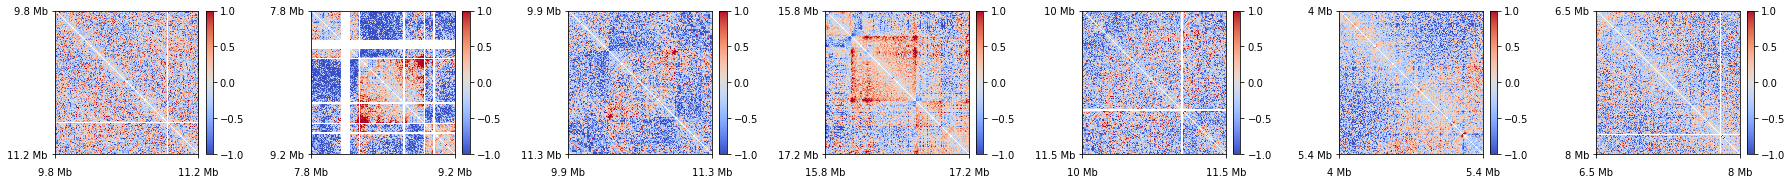

In [9]:
f, axs = plt.subplots(
    figsize=(25, 10),
    ncols=7,
    nrows=1
)

# Variables
obsexp = [-1, 1]

# S. hermaphroditum

ax = axs[0]

region = 'SHERM_X:9,800,000-11,200,000'
start, end =9_800_000, 11_200_000
extents = (start, end, end, start)

clr_region = cgi_region(sheclr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(she_expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# P. pacificus

ax = axs[1]

region = 'X:7,800,000-9,200,000'
start, end =7_800_000, 9_200_000
extents = (start, end, end, start)

clr_region = cgi_region(ppaclr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(ppa_expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# C. becei

ax = axs[2]
region = 'X:9,900,000-11,300,000'
start, end =9_900_000, 11_300_000
extents = (start, end, end, start)

clr_region = cgi_region(cbeclr, region)

## observed/expect
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(cbe_expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# C. elegans

ax = axs[3]
region = 'X:15,800,000-17,200,000'
start, end =15_800_000, 17_200_000
extents = (start, end, end, start)

clr_region = cgi_region(celclr, region)

## observed/expect
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(cel_expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# C. remanei

ax = axs[4]

region = 'X:10,000,000-11,500,000'
start, end =10_000_000, 11_500_000
extents = (start, end, end, start)

clr_region = cgi_region(creclr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(cre_expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# O. tipulae

ax = axs[5]

region = 'X:4,000,000-5,400,000'
start, end =4_000_000, 5_400_000
extents = (start, end, end, start)

clr_region = cgi_region(oticlr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(oti_expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# O. onirici

ax = axs[6]

region = 'X:6,500,000-8,000,000'
start, end =6_500_000, 8_000_000
extents = (start, end, end, start)

clr_region = cgi_region(oonclr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(oon_expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

plt.xticks(rotation=45)
plt.tight_layout(w_pad=2)

plt.savefig("chrX_zoom_all7_5kb_h_oe.pdf", format='pdf', dpi=300)

Plot observed/expected for a 1.4 mb region on chromosome I.

In [ ]:
f, axs = plt.subplots(
    figsize=(25, 10),
    ncols=7,
    nrows=1
)

# Variables
obsexp = [-1, 1]

# S. hermaphroditum

ax = axs[0]

region = 'SHERM_I:3,000,000-4,400,000'
start, end =3_000_000, 4_400_000
extents = (start, end, end, start)

clr_region = cgi_region(sheclr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(she_expected_I['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# P. pacificus

ax = axs[1]

region = 'I:8,800,000-10,200,000'
start, end =8_800_000, 10_200_000
extents = (start, end, end, start)

clr_region = cgi_region(ppaclr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(ppa_expected_I['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# C. becei

ax = axs[2]
region = 'I:4,800,000-7,200,000'
start, end =4_800_000, 7_200_000
extents = (start, end, end, start)

clr_region = cgi_region(cbeclr, region)

## observed/expect
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(cbe_expected_I['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# C. elegans

ax = axs[3]
region = 'I:7,500,000-8,900,000'
start, end =7_500_000, 8_900_000
extents = (start, end, end, start)

clr_region = cgi_region(celclr, region)

## observed/expect
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(cel_expected_I['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# C. remanei

ax = axs[4]

region = 'I:6,500,000-8,000,000'
start, end =6_500_000, 8_000_000
extents = (start, end, end, start)

clr_region = cgi_region(creclr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(cre_expected_I['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# O. tipulae

ax = axs[5]

region = 'I:4,000,000-5,400,000'
start, end =4_000_000, 5_400_000
extents = (start, end, end, start)

clr_region = cgi_region(oticlr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(oti_expected_I['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

# O. onirici

ax = axs[6]

region = 'I:4,500,000-6,000,000'
start, end =4_500_000, 6_000_000
extents = (start, end, end, start)

clr_region = cgi_region(oonclr, region)

## observed/expected
divider = make_axes_locatable(ax)
obs_exp = clr_region / linalg.toeplitz(oon_expected_I['balanced.avg'][0:len(clr_region)])   
im_oe = ax.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0], vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax, rotate=False)
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False, pad=10)
ax.set_xticks([start, end])
ax.set_yticks([start, end])

plt.xticks(rotation=45)
plt.tight_layout(w_pad=2)

plt.savefig("chrA_zoom_all7_5kb_h_oe.pdf", format='pdf', dpi=300)